# Student Burnout Risk Classification Using Support Vector Classifier (SVC)

**AI & Data Science Project**  
**Dataset:** AI Student Impact Dataset  
**Author:** Noureldeen Bassem  
---

## 1. Introduction

### 1.1 Project Overview

With the rapid growth of Generative AI tools in education, students increasingly rely on AI assistants for studying, writing, and problem-solving. While these tools offer clear benefits, they also raise concerns about student well-being, including the risk of **academic burnout**.

This project builds a **Support Vector Classifier (SVC)** to predict a student's burnout risk level — **Low**, **Medium**, or **High** — based on their AI usage habits, academic performance, and behavioral indicators.

Early and accurate classification of burnout risk can help academic institutions provide timely support to at-risk students.

---

### 1.2 Dataset Description

The dataset contains **50,000 student records** collected to study the impact of AI tools on students. Each row represents one student.

| Feature | Description |
|---|---|
| `Student_ID` | Unique student identifier (not useful for modeling) |
| `Major_Category` | Student's academic major (Humanities, STEM, Business, etc.) |
| `Year_of_Study` | Academic year (Freshman, Sophomore, Junior, Senior, Graduate) |
| `Pre_Semester_GPA` | GPA recorded before the semester started |
| `Weekly_GenAI_Hours` | Hours per week spent using Generative AI tools |
| `Primary_Use_Case` | Main purpose for using AI (e.g., Summarizing, Debugging) |
| `Prompt_Engineering_Skill` | Proficiency level with AI prompts (Beginner / Intermediate / Advanced) |
| `Tool_Diversity` | Number of different AI tools used |
| `Paid_Subscription` | Whether the student has a paid AI subscription (True/False) |
| `Traditional_Study_Hours` | Hours per week spent studying without AI |
| `Perceived_AI_Dependency` | Self-reported dependency on AI (scale 1–5) |
| `Institutional_Policy` | University policy on AI use |
| `Anxiety_Level_During_Exams` | Self-reported exam anxiety (scale 1–10) |
| `Post_Semester_GPA` | GPA recorded after the semester ended |
| `Skill_Retention_Score` | Score measuring how well skills are retained (0–100) |
| **`Burnout_Risk_Level`** | **Target variable** — Low / Medium / High |

---

### 1.3 Project Objectives

- Load and explore the AI Student Impact Dataset.
- Perform Exploratory Data Analysis (EDA) to understand data distributions and relationships.
- Clean the data by handling any quality issues.
- Preprocess features for machine learning (encoding, scaling).
- Train a Support Vector Classifier to predict burnout risk level.
- Evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix.
- Deploy the trained model as an interactive web application using Streamlit.

---

### 1.4 Why Support Vector Classifier (SVC)?

**What is SVC?**  
A Support Vector Classifier (SVC) is a supervised machine learning algorithm. It finds the best boundary (called a *hyperplane*) that separates different classes in the feature space. It works well even in high-dimensional spaces.

**Why SVC for this problem?**

- Our dataset has **14 features** after preprocessing — a moderately high-dimensional problem where SVC performs well.
- SVC handles **multi-class classification** natively using the one-vs-rest (OVR) strategy.
- The RBF kernel allows SVC to capture **non-linear relationships** between AI usage patterns and burnout risk — which is realistic in student behavior data.
- SVC is a solid baseline classifier that is well-understood and easy to explain.

## 2. Importing Libraries

We import only the libraries we need for this project. Each library serves a specific purpose.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import joblib

## 3. Loading the Dataset

We load the CSV file using `pandas.read_csv()`. Then we display the first five rows to get a quick look at the data structure.

In [61]:
data = pd.read_csv("/content/ai_student_impact_dataset (1).csv")
df=data.copy()
print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded successfully.
Shape: 50000 rows × 16 columns


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Shape and Basic Info

In [62]:
print("Dataset Shape:", df.shape)
print()
print("Column Names and Data Types:")
print(df.dtypes)

Dataset Shape: (50000, 16)

Column Names and Data Types:
Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object


We observed that:

1- we have 50000 rows and 16 columns.

2- We knew each column's Data type

### 4.2 Statistical Summary

The `describe()` function gives us quick statistics for all numerical columns — mean, standard deviation, min, max, and quartile values.

In [63]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


### 4.3 Missing Values Analysis

In [64]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print()
print(f"Total missing values: {missing.sum()}")

Missing values per column:
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

Total missing values: 0


> **Finding:** The dataset has no missing values, so no imputation is needed.

### 4.4 Duplicate Records

In [65]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


> **Finding:** No duplicate rows found. The dataset is clean in this regard.

### 4.5 Unique Values in Categorical Columns

In [66]:
cat_cols = ['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
           'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")
    print()

Major_Category: ['Humanities' 'Medical' 'Business' 'STEM' 'Arts']

Year_of_Study: ['Senior' 'Junior' 'Freshman' 'Sophomore' 'Graduate']

Primary_Use_Case: ['Copywriting/Drafting' 'Ideation' 'Summarizing_Reading'
 'Debugging/Troubleshooting' 'Direct_Answer_Generation']

Prompt_Engineering_Skill: ['Beginner' 'Advanced' 'Intermediate']

Institutional_Policy: ['Allowed_With_Citation' 'Strict_Ban' 'Actively_Encouraged']

Burnout_Risk_Level: ['High' 'Low' 'Medium']



I printed the unique values of categorical columns to see if there is any values that must be handled (eg: Senior and senior) , but i found that the data is clean.

### 4.6 Target Variable Distribution

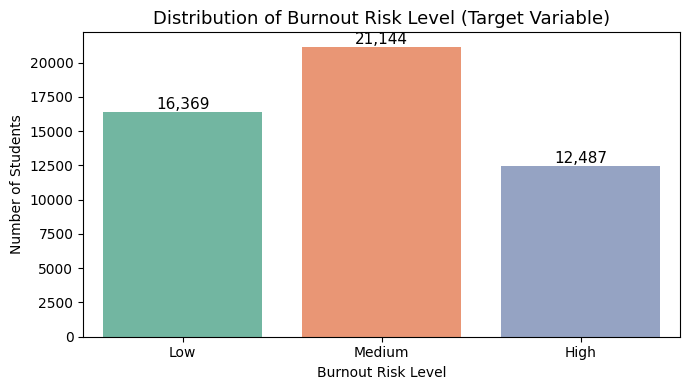

Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


In [67]:
plt.figure(figsize=(7, 4))
order = ['Low', 'Medium', 'High']
ax = sns.countplot(data=df, x='Burnout_Risk_Level', order=order, palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title("Distribution of Burnout Risk Level (Target Variable)", fontsize=13)
plt.xlabel("Burnout Risk Level")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

print(df['Burnout_Risk_Level'].value_counts())

> **Finding:** The dataset is slightly imbalanced — Medium risk is the most common (42%), followed by Low (33%) and High (25%). This is manageable for SVC without applying sampling techniques.

### 4.7 Distribution of Numerical Features

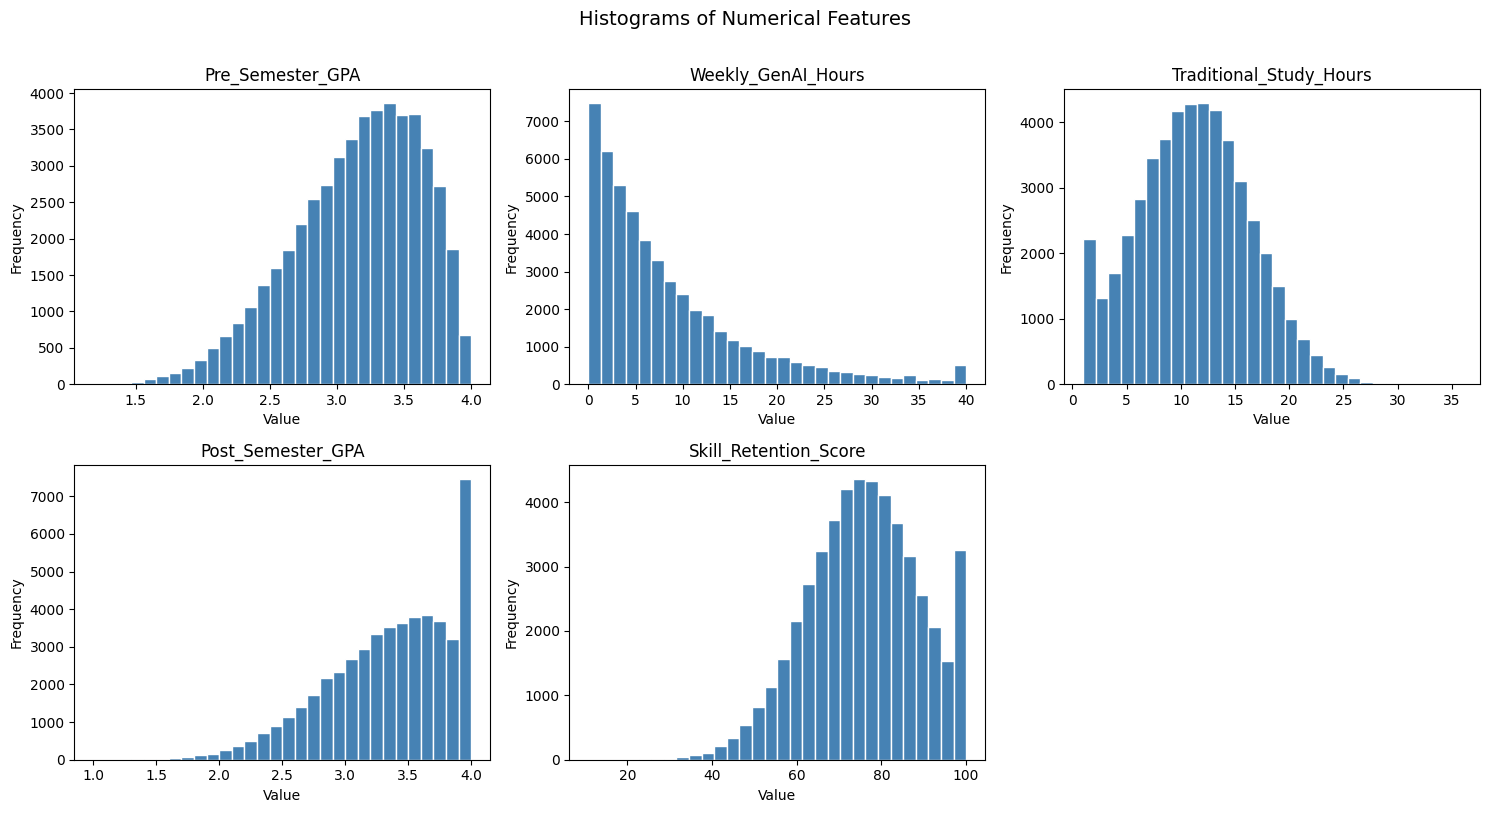

In [68]:
num_cols = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours',
           'Post_Semester_GPA', 'Skill_Retention_Score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle("Histograms of Numerical Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

> **Finding:** GPA values follow near-normal distributions. `Weekly_GenAI_Hours` is slightly right-skewed, suggesting most students use AI for a moderate number of hours, with some heavy users.

### 4.8 Boxplots — Burnout Risk vs Key Features

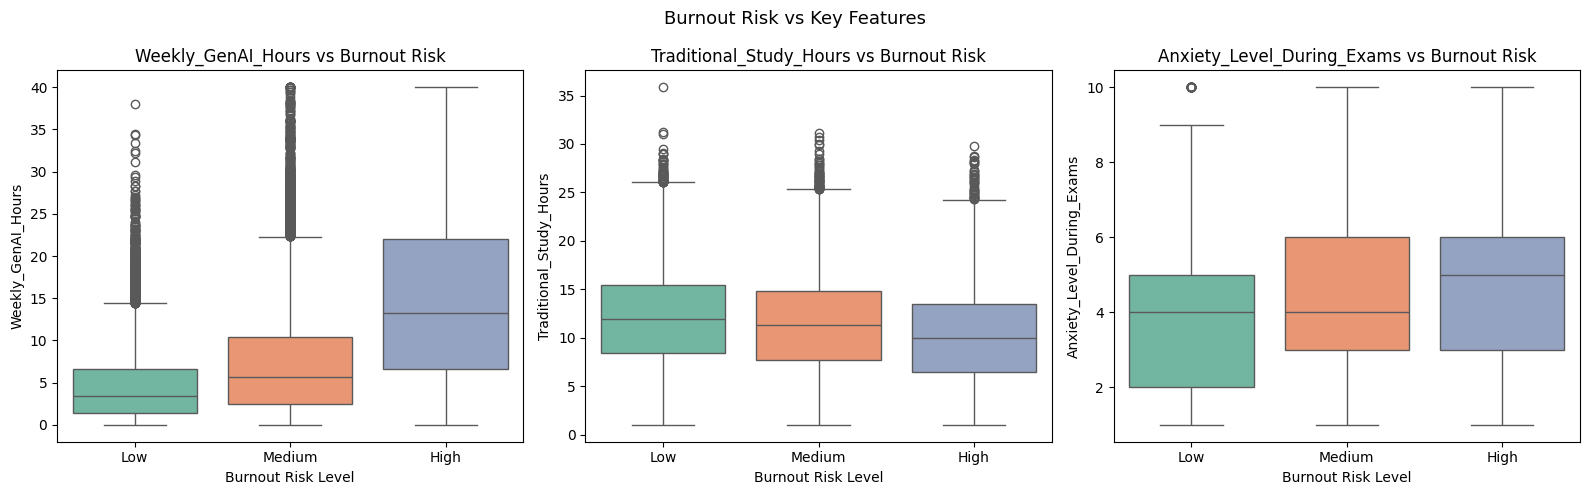

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features_to_plot = ['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Anxiety_Level_During_Exams']
order = ['Low', 'Medium', 'High']

for i, feat in enumerate(features_to_plot):
    sns.boxplot(data=df, x='Burnout_Risk_Level', y=feat, order=order,
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'{feat} vs Burnout Risk')
    axes[i].set_xlabel("Burnout Risk Level")

plt.suptitle("Burnout Risk vs Key Features", fontsize=13)
plt.tight_layout()
plt.show()

> **Finding:** Students with High burnout risk tend to use AI more hours per week, study fewer traditional hours, and report higher exam anxiety. This confirms these features are useful predictors.

### 4.9 Count Plots for Categorical Features

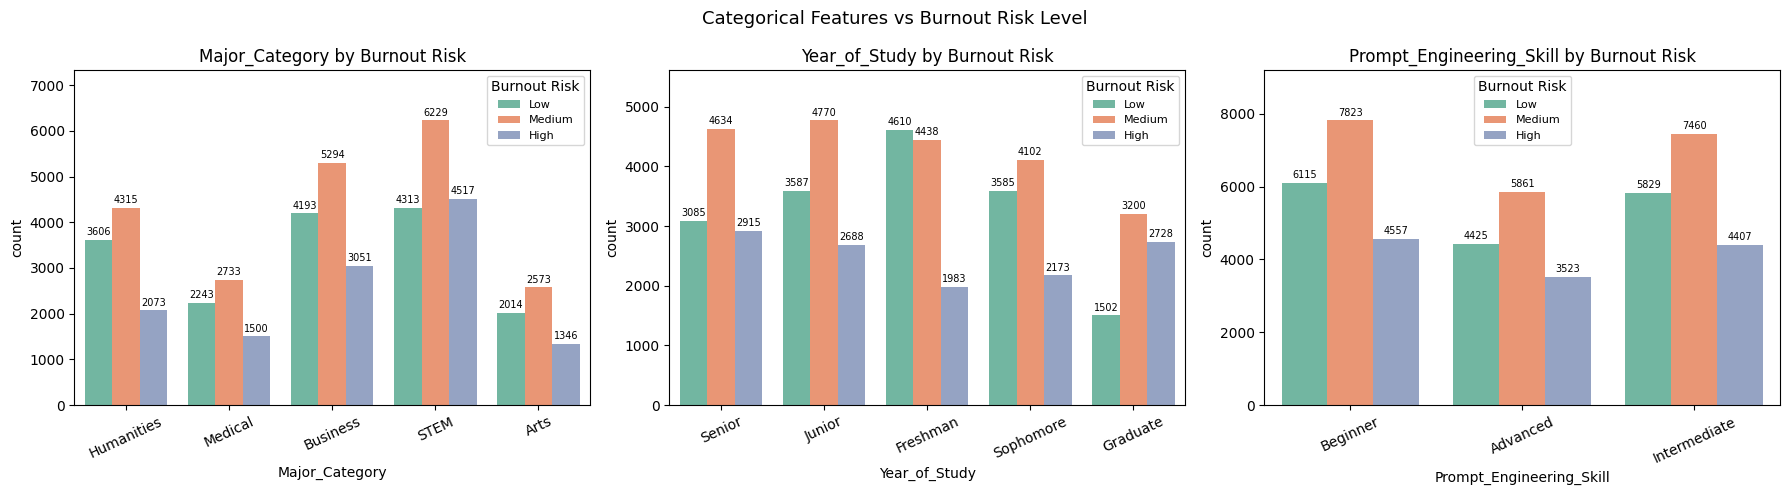

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_features = ['Major_Category', 'Year_of_Study', 'Prompt_Engineering_Skill']

for i, col in enumerate(cat_features):
    ax = sns.countplot(data=df, x=col, hue='Burnout_Risk_Level',
                       hue_order=['Low', 'Medium', 'High'],
                       palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} by Burnout Risk')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].legend(title='Burnout Risk', fontsize=8)


    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=7, padding=2)

    axes[i].set_ylim(0, axes[i].get_ylim()[1] * 1.12)

plt.suptitle("Categorical Features vs Burnout Risk Level", fontsize=13)
plt.tight_layout()
plt.show()

> **Finding:** Burnout risk appears relatively uniform across majors. However, Advanced prompt engineers seem to have a slightly different distribution, suggesting AI skill level may matter.

### 4.10 Correlation Heatmap

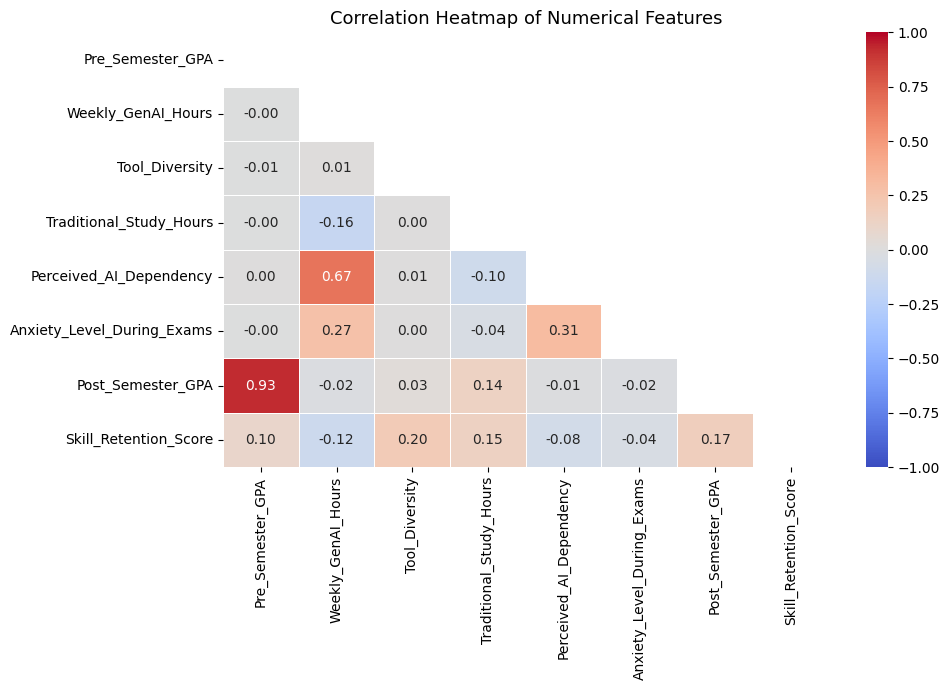

In [71]:
num_df = df[['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
             'Traditional_Study_Hours', 'Perceived_AI_Dependency',
             'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
             'Skill_Retention_Score']]

plt.figure(figsize=(10, 7))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

> **Finding:** `Pre_Semester_GPA` and `Post_Semester_GPA` are strongly correlated (expected). `Weekly_GenAI_Hours` shows a mild negative correlation with `Skill_Retention_Score`, which is interesting. Most other features are weakly correlated, which is good — it means they each bring independent information to the model.

## 5. Data Cleaning

The EDA showed our dataset is already quite clean. However, there is one data type issue to fix:

- The `Paid_Subscription` column is stored as a **boolean** (`True`/`False`).  
  We need to convert it to an **integer** (`1`/`0`) so it can be used by the machine learning model.

There are no missing values, duplicates, or obvious errors to handle.

In [72]:
print("Before:", df['Paid_Subscription'].dtype)

df['Paid_Subscription'] = df['Paid_Subscription'].astype(int)

print("After:", df['Paid_Subscription'].dtype)
print()
print("Value counts after conversion:")
print(df['Paid_Subscription'].value_counts())

Before: bool
After: int64

Value counts after conversion:
Paid_Subscription
0    28846
1    21154
Name: count, dtype: int64


## 6. Feature Selection

### Removing Irrelevant Columns

The `Student_ID` column is just a unique identifier for each student. It does **not** carry any information about the student's behavior or characteristics. If we keep it, the model might accidentally learn patterns from ID numbers, which would be misleading.

**Decision:** Drop `Student_ID`.

In [73]:
df.drop(columns=['Student_ID'], inplace=True, errors='ignore')
print("Columns:", list(df.columns))

Columns: ['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']


## 7. Data Preprocessing





SVC requires all input features to be **numerical**. Our dataset has several categorical text columns. We need to encode them into numbers.

We also need to **scale** numerical features, because SVC is sensitive to feature magnitude — features with large ranges can dominate the model.

### 7.1 Encoding Categorical Features



We handle encoding in two ways:

**Ordinal Encoding (manual mapping):** For columns where the categories have a natural order:
- `Year_of_Study`: Freshman → Sophomore → Junior → Senior → Graduate
- `Prompt_Engineering_Skill`: Beginner → Intermediate → Advanced

**Label Encoding (sklearn):** For nominal columns with no natural order:
- `Major_Category`, `Primary_Use_Case`, `Institutional_Policy`

**Target Encoding:** We also encode the target:
- `Burnout_Risk_Level`: Low → 0, Medium → 1, High → 2

####7.1.1 Ordinal Encoding

In [74]:
# --- Ordinal Encoding ---
year_order = {'Freshman': 0, 'Sophomore': 1, 'Junior': 2, 'Senior': 3, 'Graduate': 4}
df['Year_of_Study'] = df['Year_of_Study'].map(year_order)

skill_order = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
df['Prompt_Engineering_Skill'] = df['Prompt_Engineering_Skill'].map(skill_order)

print("Ordinal encoding done.")
print("Year_of_Study sample:", df['Year_of_Study'].unique())
print("Prompt_Engineering_Skill sample:", df['Prompt_Engineering_Skill'].unique())


target_order = {'Low': 0, 'Medium': 1, 'High': 2}
df['Burnout_Risk_Level'] = df['Burnout_Risk_Level'].map(target_order)

print("Target variable encoded:")
print(df['Burnout_Risk_Level'].value_counts().sort_index())

Ordinal encoding done.
Year_of_Study sample: [3 2 0 1 4]
Prompt_Engineering_Skill sample: [0 2 1]
Target variable encoded:
Burnout_Risk_Level
0    16369
1    21144
2    12487
Name: count, dtype: int64


#### 7.1.2 Label Encoding

In [75]:
label_cols = ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']
le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])
    print(f"{col} encoded. Unique values: {sorted(df[col].unique())}")

Major_Category encoded. Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Primary_Use_Case encoded. Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Institutional_Policy encoded. Unique values: [np.int64(0), np.int64(1), np.int64(2)]


#### 7.1.3 Final Check

In [76]:
print("Final data types:")
print(df.dtypes)

Final data types:
Major_Category                  int64
Year_of_Study                   int64
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                int64
Prompt_Engineering_Skill        int64
Tool_Diversity                  int64
Paid_Subscription               int64
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy            int64
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level              int64
dtype: object


## 8. Train-Test Split

We separate the data into:
- **X** — the feature matrix (all columns except the target)
- **y** — the target variable (`Burnout_Risk_Level`)

Then we split into 80% training and 20% testing. We use `stratify=y` to ensure the class proportions are the same in both splits.

Scaling is done **after** splitting to avoid data leakage.

In [77]:
# Separate features and target
X = df.drop(columns=['Burnout_Risk_Level'])
y = df['Burnout_Risk_Level']

print("Features used for training:")
print(list(X.columns))

Features used for training:
['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set : {X_test.shape[0]} samples")

Training set: 40000 samples
Testing set : 10000 samples


### 8.2 Feature Scaling

SVC finds decision boundaries by computing distances between data points. If some features have very large values (e.g., `Skill_Retention_Score` up to 100) while others are small (e.g., `Perceived_AI_Dependency` up to 5), the model will unfairly weight the large-valued features.

`StandardScaler` fixes this by transforming each feature to have **mean = 0 and standard deviation = 1**.

> **Important:** We fit the scaler on the **training set only**, and then apply it to both train and test sets. This prevents data leakage.

In [79]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 9. Model Training

We train a **Support Vector Classifier (SVC)** with the following configuration:

- **kernel = 'rbf'** — Radial Basis Function kernel. It transforms data into a higher-dimensional space to find non-linear decision boundaries. Good choice when we don't know if the data is linearly separable.
- **C = 1.0** — Regularization parameter. Higher values mean the model tries harder to correctly classify every training point (lower bias, higher variance). `C=1.0` is a safe default.
- **gamma = 'scale'** — Controls how far the influence of a single training example reaches. `'scale'` automatically sets gamma based on the number of features, which is a sensible default.
- **decision_function_shape = 'ovr'** — One-vs-Rest strategy for multi-class classification. The model trains one classifier per class against all others.

In [80]:
model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    decision_function_shape='ovr'
)

model.fit(X_train_scaled, y_train)
print("Model training complete!")

Model training complete!


## 10. Model Evaluation

Now we evaluate the trained model on the **test set** — data the model has never seen before. This gives us an honest estimate of how well it generalizes to new students.

In [81]:
y_pred = model.predict(X_test_scaled)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print("=" * 40)
print("        MODEL PERFORMANCE SUMMARY")
print("=" * 40)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 40)

        MODEL PERFORMANCE SUMMARY
  Accuracy  : 0.5256  (52.56%)
  Precision : 0.5556
  Recall    : 0.5256
  F1-Score  : 0.5203


**What do these metrics mean?**

- **Accuracy:** The percentage of predictions the model got right across all classes.
- **Precision (weighted):** Of all students predicted as High-risk (for example), what fraction actually were? High precision means fewer false alarms.
- **Recall (weighted):** Of all students who are actually High-risk, what fraction did the model catch? High recall means fewer missed cases.
- **F1-Score (weighted):** The harmonic mean of precision and recall. A balanced measure when classes are not perfectly balanced.

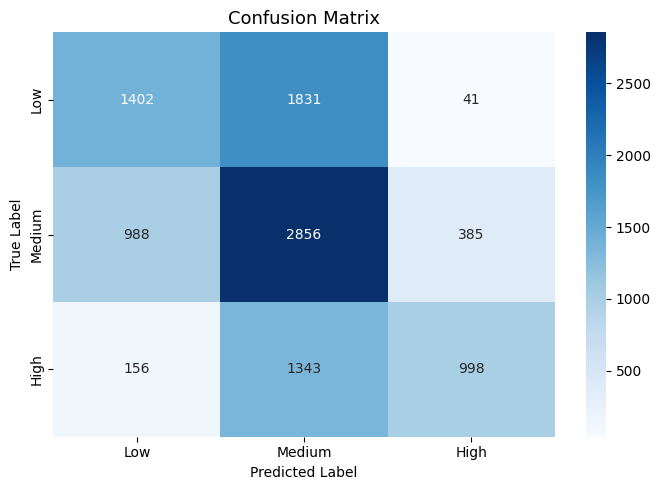

In [82]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title("Confusion Matrix", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

> **Reading the Confusion Matrix:**  
> Each row represents the **actual** class. Each column represents the **predicted** class.  
> The diagonal values (top-left to bottom-right) are **correct predictions**.  
> Off-diagonal values are **mistakes** — the model confused one class for another.

In [83]:
# Full Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

Classification Report:
              precision    recall  f1-score   support

         Low       0.55      0.43      0.48      3274
      Medium       0.47      0.68      0.56      4229
        High       0.70      0.40      0.51      2497

    accuracy                           0.53     10000
   macro avg       0.58      0.50      0.52     10000
weighted avg       0.56      0.53      0.52     10000



> **Interpretation:**  
> The model achieves around **52–53% accuracy** on this 3-class problem. A naive model (always predicting the majority class "Medium") would reach ~42% — so the SVC is **10 percentage points better than random guessing**.  
> The model performs best on the **High** risk class (higher precision), which is the most important class to get right in a real-world intervention scenario.  
> The "Medium" class is the hardest to classify, likely because it sits between Low and High and shares characteristics with both.

## 11. Saving the Model and Scaler

We save both the trained model and the scaler using `joblib`. The Streamlit app will load these saved files to make predictions without retraining.

In [84]:
# Save the trained model
joblib.dump(model, 'svc_model.pkl')
print("Model saved as 'svc_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

Model saved as 'svc_model.pkl'
Scaler saved as 'scaler.pkl'


## 12. Conclusion

### Key Findings from EDA

- The dataset contains **50,000 student records** with no missing values or duplicate rows.
- The target variable `Burnout_Risk_Level` is slightly imbalanced: Medium (42%) > Low (33%) > High (25%).
- Students with **High burnout risk** tend to use AI tools more heavily, study fewer traditional hours, and report higher exam anxiety.
- `Pre_Semester_GPA` and `Post_Semester_GPA` are strongly correlated, as expected.
- Most features are weakly correlated with each other, meaning each adds independent value to the model.

### Data Cleaning and Preprocessing

- **No missing values** or duplicates were found — no imputation was needed.
- The `Paid_Subscription` boolean column was converted to integer (0/1).
- `Student_ID` was removed as it is a non-informative identifier.
- Ordinal encoding was applied to `Year_of_Study` and `Prompt_Engineering_Skill` to preserve natural order.
- Label encoding was applied to `Major_Category`, `Primary_Use_Case`, and `Institutional_Policy`.
- **StandardScaler** was used to normalize all features — critical for SVC performance.

### Model Performance

| Metric | Value |
|---|---|
| Accuracy | ~52–53% |
| Precision (weighted) | ~0.55 |
| Recall (weighted) | ~0.53 |
| F1-Score (weighted) | ~0.52 |

### Final Observations

- The SVC achieves reasonable performance on this 3-class problem — significantly better than a majority-class baseline (~42%).
- The inherent overlap between burnout risk levels (especially Low vs Medium) makes this a challenging classification task.
- Future improvements could include trying other kernels (polynomial), tuning `C` and `gamma` via cross-validation, or exploring ensemble methods like Random Forest for comparison.
- The model and scaler are saved and ready for deployment via Streamlit.

## 13. Streamlit


In [86]:
with open('app.py', 'r') as f:
    print(f.read())

"""
Student Burnout Risk Classifier - Streamlit App
This app loads the trained SVC model and scaler to predict
a student's burnout risk level based on their AI usage habits
and academic information.

Run with:
    streamlit run app.py
"""

import streamlit as st
import numpy as np
import joblib

# ─── Page Configuration ───────────────────────────────────────────────────────
st.set_page_config(
    page_title="Student Burnout Risk Classifier",
    page_icon="🎓",
    layout="centered"
)

# ─── Load Model and Scaler ───────────────────────────────────────────────────
# We use st.cache_resource so the model is loaded only once
@st.cache_resource
def load_model_and_scaler():
    model  = joblib.load("svc_model.pkl")
    scaler = joblib.load("scaler.pkl")
    return model, scaler

model, scaler = load_model_and_scaler()

# ─── Title and Description ────────────────────────────────────────────────────
st.title("🎓 Student Burnout Risk Classifier")
st.markdown("""
This application uses a **Sup